<a href="https://colab.research.google.com/github/Simran-Dalvi/TensorFlow/blob/main/01_neural_network_regresion_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Regression with neural networks in TensorFlow

There are many definitions for our regression proble, in our case:

Predicting a numerical variables based on some other combinations of variables (predicting a number).

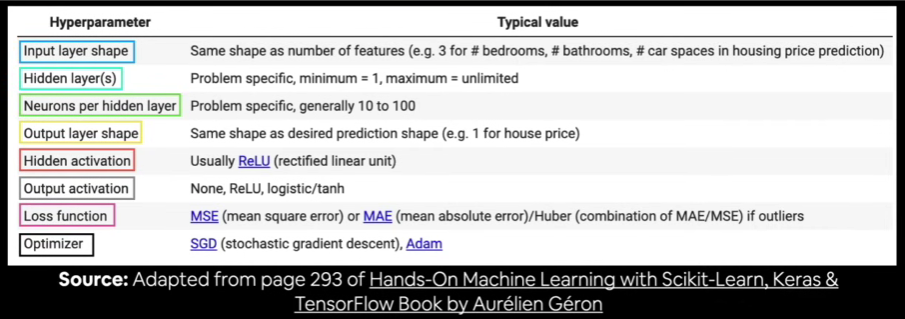

In [ ]:
# Import tensorflow

import tensorflow as tf
print(tf.__version__)

2.19.0


### Creating some data to view and fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

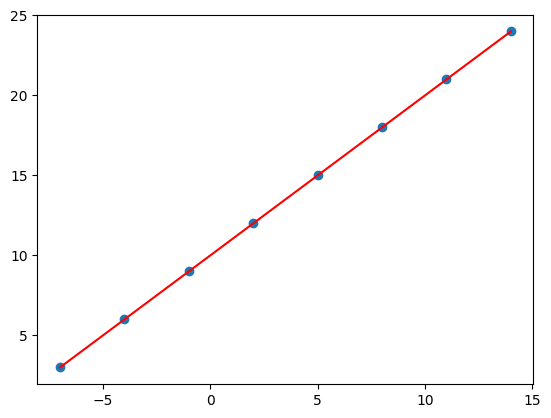

In [ ]:
#create features

X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

#visualize it
plt.scatter(X, y)
plt.plot(X, y, color='red')

In [ ]:
# how do we manipulate X to get y
X + 10
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and Output shapes

In [ ]:
# create a demo tensor for our housing price prediction problems

house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
# turn our numpy arrays into tensor

X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [ ]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

(TensorShape([8]), TensorShape([8]))

### Steps in modeling with TensorFlow

1. Create a model - define the input and output layers, as well as the hidden layers of a deep learning model.

2. Compiling a model - define the
* loss function (in other words, the function which tells our model how wrong it is) and
* the optimizer (tells our model how to improve the patterns its learning) and
* evaluation metrics (what we can use to interpret the performance of our model)

3. Fitting the model - letting the model try to find patterns between X and y (feature and labels).
* Epochs (how many times the model will go through all of the training examples.)

4. Evaluate the model - how reliable are our model's predictions.

5. Inprove through experimantation

6. Save the model

In [ ]:
X = tf.cast(X, dtype = tf.float32)

In [ ]:
# X = tf.reshape(X, shape=(-1,1))

In [ ]:
X

<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>

In [ ]:
# Set the random seed

tf.random.set_seed(42)

# create a model using the sequential API

model_a = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,)) # changing the input shape cause features are always taken as 2D
])

# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(1)
# ])

# 2. compile the model
model_a.compile(loss= tf.keras.losses.mae, # mean absolute error
              optimizer = tf.keras.optimizers.SGD(), # stochastic gradient descent
              metrics= ["mae"]
              )

# 3. fit the model
model_a.fit(X, y, epochs = 5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step - loss: 16.8176 - mae: 16.8176
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 16.5364 - mae: 16.5364
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 16.2551 - mae: 16.2551
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 15.9739 - mae: 15.9739
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 15.6926 - mae: 15.6926


In [ ]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [ ]:
X[0]

<tf.Tensor: shape=(), dtype=float32, numpy=-7.0>

In [ ]:
# try and make a prediction using a model
model_a.predict(tf.constant([17.], dtype= tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


array([[-8.671359]], dtype=float32)

In [ ]:
y_pred_a = model_a.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


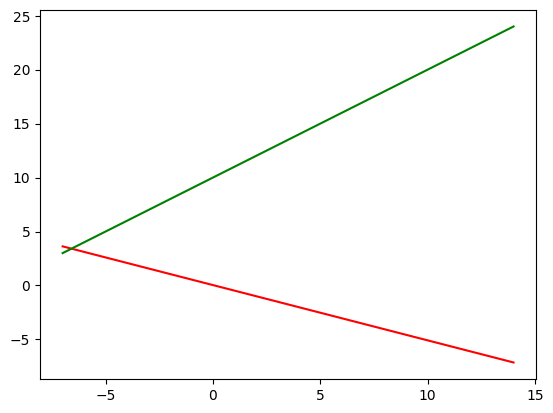

In [ ]:
# plt.scatter(X, y_pred)
plt.plot(X, y_pred_a, color='red')
plt.plot(X, y, color='green')
plt.show()

### How we can improve the model

we can improve our model by altering the steps we took to create a model

1. create a model - we might add more layers, increase the number of hidden units (also called neurons) within each of the hidden layer, change the activation function of each layer.

2.  Compiling the model - we might change the optimization function or perhaps the learning rate of the optimization function.

3. Fitting the model - here we might fit the model for more epochs (leave it training for longer) or on more data (give the model more examples to learn from).

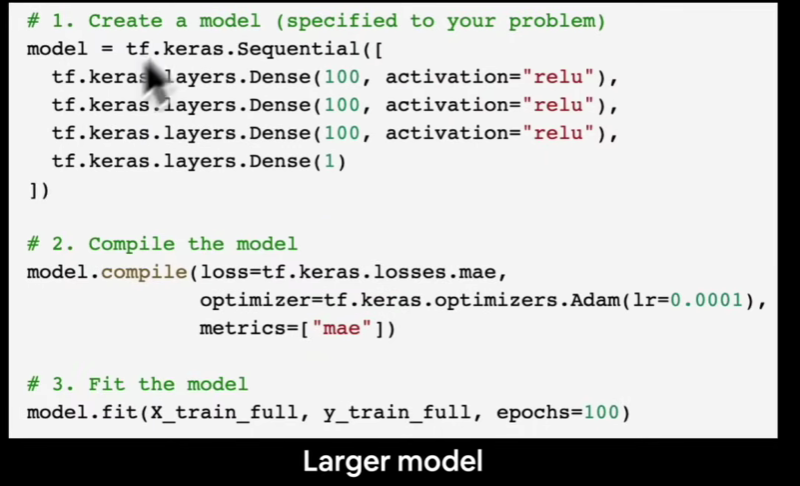

In [ ]:
y = tf.cast(y, dtype = tf.float32)
X = tf.reshape(X, shape=(-1,1))

X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# lets rebuild our model
# 1. create our model

model_b = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. compile the model

model_b.compile(loss='mae',
              optimizer= 'sgd',
              metrics= ['mae']
            )

# 3. fit the model (this time we will fit for longer)
model_b.fit(X, y, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step - loss: 17.8397 - mae: 17.8397
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 17.5585 - mae: 17.5585
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 17.2772 - mae: 17.2772
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 16.9960 - mae: 16.9960
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 16.7147 - mae: 16.7147
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 16.4335 - mae: 16.4335
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 16.1522 - mae: 16.1522
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 15.8710 - mae: 15.8710
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 15.5897 - mae: 15.5897
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 15.3085 - mae: 15.3085
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 15.0272 - mae: 15.0272
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 14.7894 - mae: 14.7894
Epoch 13/100
1/1 ━━━━━━

In [ ]:
# prediction

model_b.predict(tf.constant([17.], dtype = tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


array([[29.338932]], dtype=float32)

In [ ]:
X

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]], dtype=float32)>

In [ ]:
y_pred_b = model_b(X.numpy())

In [ ]:
y_pred_b

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[-10.81368   ],
       [ -5.7946024 ],
       [ -0.77552605],
       [  4.2435503 ],
       [  9.262627  ],
       [ 14.281703  ],
       [ 19.30078   ],
       [ 24.319857  ]], dtype=float32)>

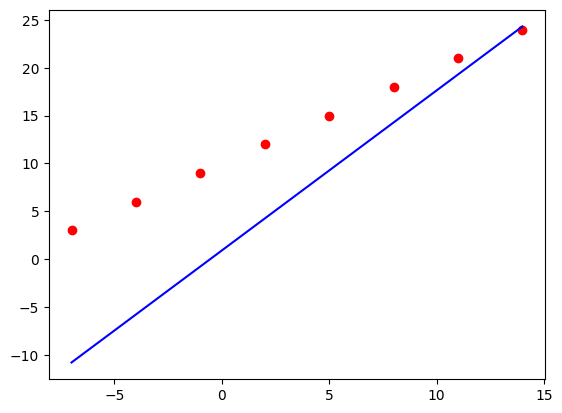

In [ ]:
plt.scatter(X, y, color='red')
plt.plot(X, y_pred_b, color='blue')

In [ ]:
# lets see if we can make another change to imporve it

model_c = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_c.compile(loss= 'mae',
              optimizer = 'sgd',
              metrics= ["mae"])

model_c.fit(X, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step - loss: 13.2514 - mae: 13.2514
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.5767 - mae: 12.5767
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 11.8958 - mae: 11.8958
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.2036 - mae: 11.2036
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 10.4966 - mae: 10.4966
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9.7702 - mae: 9.7702
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 9.0086 - mae: 9.0086
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.2150 - mae: 8.2150
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.3879 - mae: 7.3879
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 6.5050 - mae: 6.5050
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 5.5604 - mae: 5.5604
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.5909 - mae: 4.5909
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model_c.predict(tf.constant([17.], dtype = tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


array([[31.552662]], dtype=float32)

In [ ]:
y_pred_c = model_c(X)
y_pred_c

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[ 2.9899004 ],
       [ 1.9836731 ],
       [ 0.97744554],
       [ 4.6315985 ],
       [10.015843  ],
       [15.400088  ],
       [20.784332  ],
       [26.168581  ]], dtype=float32)>

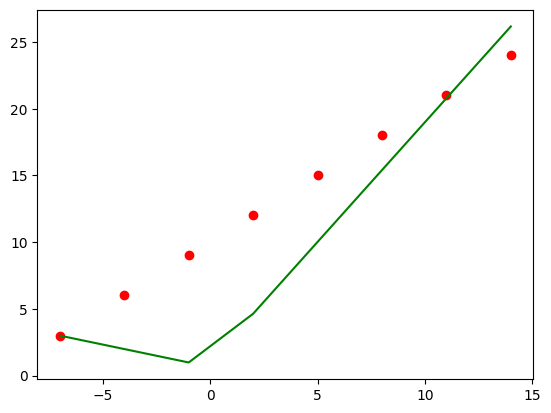

In [ ]:
plt.scatter(X, y, color = 'red')
plt.plot(X, y_pred_c, color='green')

In [ ]:
model_d = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_d.compile(loss='mae',
                optimizer='sgd',
                metrics = ['mae'])

model_d.fit(X, y, epochs=100)

y_pred_d = model_d(X)
y_pred_d

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13.4309 - mae: 13.4309
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step - loss: 13.1852 - mae: 13.1852
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12.9764 - mae: 12.9764
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 12.7999 - mae: 12.7999
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 12.6130 - mae: 12.6130
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 12.4114 - mae: 12.4114
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 12.1818 - mae: 12.1818
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 11.9068 - mae: 11.9068
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 11.5654 - mae: 11.5654
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 11.1387 - mae: 11.1387
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 10.6062 - mae: 10.6062
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.8930 - mae: 9.8930
Epoch 13/100
1/1 ━━━━━━━━━

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[ 3.5895178],
       [ 3.4496593],
       [ 3.2581518],
       [ 6.63473  ],
       [11.169628 ],
       [15.7101755],
       [20.252697 ],
       [24.79531  ]], dtype=float32)>

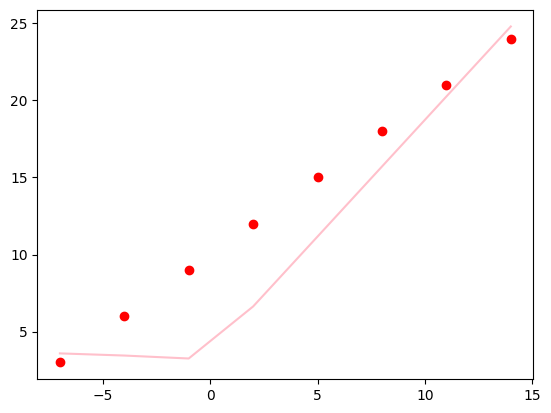

In [ ]:
plt.scatter(X, y, color='red')
# plt.plot(X, y_pred_a, color="red")
# plt.plot(X, y_pred_b, color="blue")
# plt.plot(X, y_pred_c, color="grey")
plt.plot(X, y_pred_d, color="pink")


adding more layers dosent necessrily increase the models accuracy

Common methods of improving a deep model:
* adding more layers
* increase the number of hidden units
* changing the activation functions
* change the optimization function
* change the learning rate
* fitting on more data
* fittling for longer

In [ ]:
model_e = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

model_e.compile(loss="mae",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics = ["mae"])

model_e.fit(X, y, epochs=100)

y_pred_e = model_e(X)
y_pred_e

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 14.7738 - mae: 14.7738
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 14.0980 - mae: 14.0980
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 13.4222 - mae: 13.4222
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 12.7426 - mae: 12.7426
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 12.0568 - mae: 12.0568
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.3627 - mae: 11.3627
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.6583 - mae: 10.6583
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 9.9416 - mae: 9.9416
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 9.2102 - mae: 9.2102
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 8.4616 - mae: 8.4616
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7.6929 - mae: 7.6929
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 6.9014 - mae: 6.9014
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[ 3.505235],
       [ 6.317887],
       [ 9.13054 ],
       [11.943192],
       [14.755843],
       [17.568495],
       [20.38115 ],
       [23.193802]], dtype=float32)>

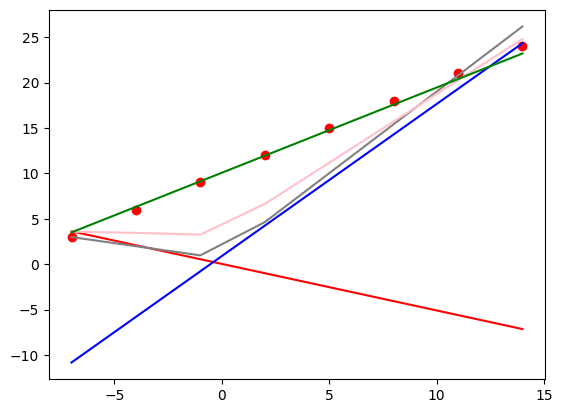

In [ ]:
plt.scatter(X, y, color='red')
plt.plot(X, y_pred_a, color="red")
plt.plot(X, y_pred_b, color="blue")
plt.plot(X, y_pred_c, color="grey")
plt.plot(X, y_pred_d, color="pink")
plt.plot(X, y_pred_e, color="green")

adjusting the learning rate of our optimizer has been the the best thing so far

so, the learning rate is the most important hyperparameter of many neural networks

### Evaluating our models performance

In practice a typical workflow will go through when building neural network is:
```
Build a model -> fit it -> evaluate it -> tweak our model -> fit it -> evaluate it -> tweak our model

when building a model:
```
Experiment... Experiment... Experiment
```

when evaluating the model:
```
Visualize... Visualize... Visualize!!
```

Its a good idea to visualize:
* the data - what data are we working with?
* the model - what does our model look like?
* the training of a model - how does a model perform while it learns?
* the predictions of the model - how do the predictions of a model line up against the ground truth (the original labels)?

In [ ]:
# make a bigger data set
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
# Make a label for the datasset

y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

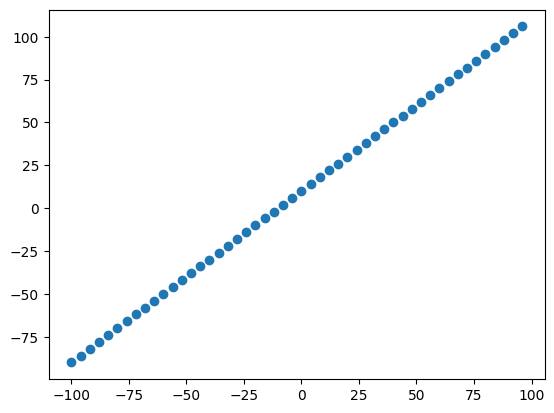

In [ ]:
# Visualize the data
plt.scatter(X, y)

### 3 sets
Generalization - the ability for a machine learning model to perform well on data it hasn't seen before.

train, test and validation sets

*  Training set- the model learns from this data, which is typically 70-80% of the totla data you have available. (Course materical)
* Validation set - the model gets tuned on this data, which is typically 10-15% of the data available. (practice tests)
* Test set - the model gets evaluated on this data to test what it has learned, this set is typically 10-155 of the total data available. (Final Exam)

In [ ]:
# check the length of samples
len(X)

50

In [ ]:
# split the data into train and test set
X_train = X[:40] # 80% of the data
X_test = X[40:] # last 20% of data

y_train = y[:40]
y_test = y[40:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualizing the data

now that we got them in training and test set... lets visualize them

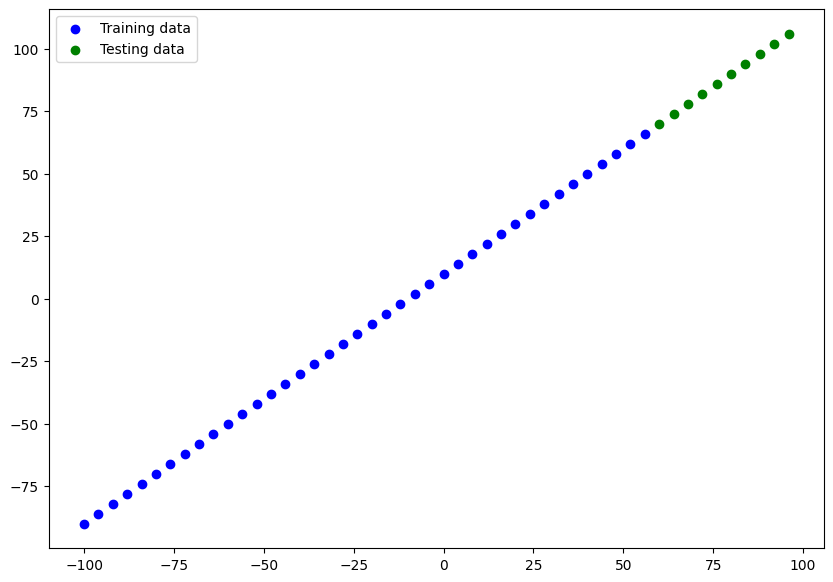

In [ ]:
plt.figure(figsize = (10, 7))
plt.scatter(X_train, y_train, c='b', label = "Training data")
plt.scatter(X_test, y_test, c='g', label = "Testing data")
plt.legend()
plt.show()

In [ ]:
# lets have a look at how to make a neural network for this data
# first changing the dtype

def change_dtype(*arrays):
  return [tf.cast(arr, tf.float32) for arr in arrays]

X_train, X_test, y_train, y_test = change_dtype(X_train, X_test, y_train, y_test)

The `*` in:

```def change_dtype(*arrays):```


is called the “argument unpacking operator” (or “variadic arguments”).

>“This function can accept any number of positional arguments, and they will be collected into a tuple called arrays.”

In [ ]:
X_train

<tf.Tensor: shape=(40,), dtype=float32, numpy=
array([-100.,  -96.,  -92.,  -88.,  -84.,  -80.,  -76.,  -72.,  -68.,
        -64.,  -60.,  -56.,  -52.,  -48.,  -44.,  -40.,  -36.,  -32.,
        -28.,  -24.,  -20.,  -16.,  -12.,   -8.,   -4.,    0.,    4.,
          8.,   12.,   16.,   20.,   24.,   28.,   32.,   36.,   40.,
         44.,   48.,   52.,   56.], dtype=float32)>

In [ ]:
# next reshape the data to become 2D
X_train = tf.reshape(X_train, shape = (-1,1))
X_test = tf.reshape(X_test, shape = (-1,1))

* Total params - total number of parameters in the model.
* Trainable parameters - these are the parameters (patterns) the model can update as it trains.
* Non- trainable params - these parameters aren't updates during training (this is typically when you bring in already learned parameter from other models during transfer learning).

The trainable parameters (also called learnable params) anr the weights and biases of the layer.

In [ ]:
# model_x = tf.keras.Sequential([
#     tf.keras.layers.Dense(10, input_shape =[1], name = "Input"),
#     tf.keras.layers.Dense(1, name="output")
# ], name = "one of the many models we are going to build..."
#                               )

# model_x.compile(loss = tf.keras.losses.mae,
#                 optimizer = tf.keras.optimizers.SGD(),
#                 metrics = ["mae"])

# model_x.summary()

In [ ]:
# from tensorflow.keras.utils import plot_model
# plot_model(model_x, show_shapes=True)

In [ ]:
# lets have a look at how to make a neural network for this data

#1. create model
model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(50, activation=None, input_shape = (1,)), # specifying input_shape is not required
        tf.keras.layers.Dense(1)
    ]
)

#2. model compile
model.compile(loss='mae',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics = ['mae'])

#3. Fitting the model
model.fit(X_train, y_train, epochs = 100, verbose=0)

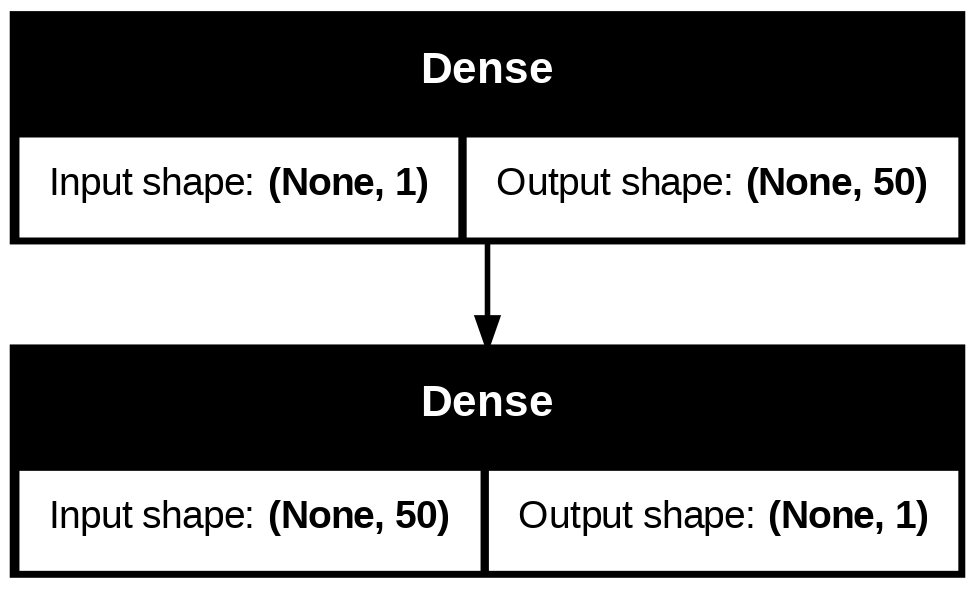

In [ ]:
#visualizing th model
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

### Visualizing the model's predictions

To visualize predictions, its a good idea to plot them against the ground truth labels.

Often you'll see this in the form of `y_test` or `y_true` versus `y_pred` (ground truth versus your model's predictions)

In [ ]:
# Make some predictions
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


array([[ 72.195496],
       [ 76.3411  ],
       [ 80.48672 ],
       [ 84.63233 ],
       [ 88.77795 ],
       [ 92.92356 ],
       [ 97.069176],
       [101.21478 ],
       [105.360405],
       [109.50601 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
      dtype=float32)>

> **Note:** If you feel like you're going to reuse some kind of function in the future, its a good idea to put then in a python function.


In [ ]:
# lets create a plotting function

def plot_preddictions(train_data = X_train,
                      train_labels = y_train,
                      test_data = X_test,
                      test_labels = y_test,
                      predictions = y_pred
                      ):
  """
  Plot training data, test data and compare predictions to ground truth labels.

  """
  plt.figure(figsize = (10,7))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c='b', label = "training data")
  # plot testing data in green
  plt.scatter(test_data, test_labels, c='g', label = "testing data")
  # plt models predictions in red
  plt.plot(test_data, predictions, c = 'r', label = "predictions")
  # show the legend
  plt.legend()
  plt.show()

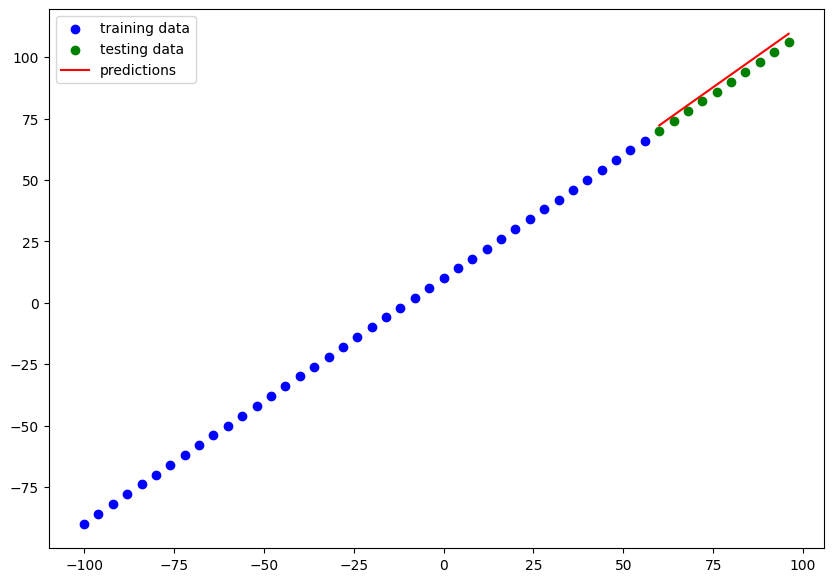

In [ ]:
plot_preddictions(train_data = X_train,train_labels = y_train,
                  test_data = X_test, test_labels = y_test, predictions = y_pred)

### Evaluating our models predictions with regression evaluation metrics

Depending on the problem you are working on,  there will be different  evaluation metrics to evaluate your model's performance.

Since we are working on regression , two of the main metrics:
* MAE (Mean Absolute Error) on average, how wrong is each of my model's prediction.
* MSE (Mean Square Error) squares the average error.

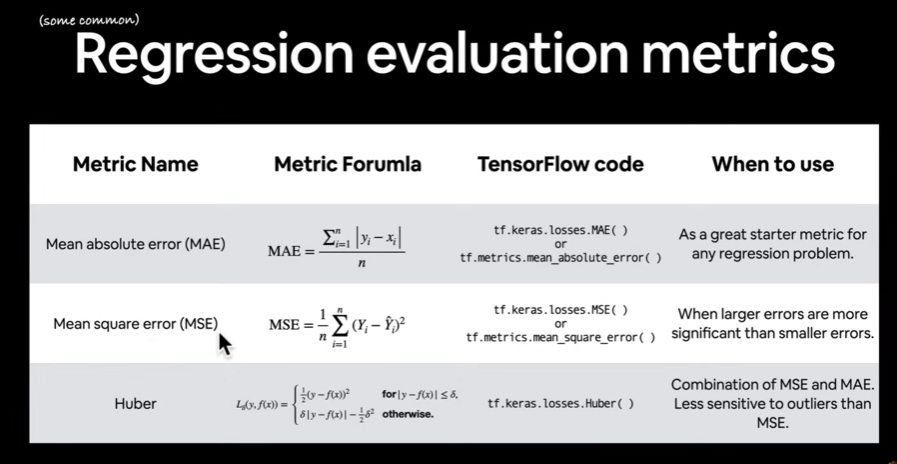

In [ ]:
#Evaluate the moedl on the test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - loss: 2.8508 - mae: 2.8508


[2.85075306892395, 2.85075306892395]

In [ ]:
y_pred

array([[ 72.195496],
       [ 76.3411  ],
       [ 80.48672 ],
       [ 84.63233 ],
       [ 88.77795 ],
       [ 92.92356 ],
       [ 97.069176],
       [101.21478 ],
       [105.360405],
       [109.50601 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
      dtype=float32)>

In [ ]:
# calculate the mae on your own
tf.metrics.mae(y_test, y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([2.1954956, 2.3411026, 2.4867172, 2.6323318, 2.7779465, 2.923561 ,
       3.0691757, 3.2147827, 3.360405 , 3.506012 ], dtype=float32)>

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
      dtype=float32)>

In [ ]:
y_pred = tf.squeeze(y_pred)
y_pred

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 72.195496,  76.3411  ,  80.48672 ,  84.63233 ,  88.77795 ,
        92.92356 ,  97.069176, 101.21478 , 105.360405, 109.50601 ],
      dtype=float32)>

In [ ]:
# Calculate the mae

tf.metrics.mae(y_test, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=2.85075306892395>

In [ ]:
#claculate the mean squared error
tf.metrics.mse(y_test, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=8.30172061920166>

MSE will typically be higher than MAE.

when larger errors are more significant than smaller errors.

eg. - 100 as error is worse than 10

In [ ]:
# Make some functions to reuse MSE and MAE

class RegressionMetrics:

  @staticmethod
  def mae(y_true, y_pred):
    return tf.metrics.mae(y_true, tf.squeeze(y_pred))

  @staticmethod
  def mse(y_true, y_pred):
    return tf.metrics.mse(y_true, tf.squeeze(y_pred))

`@staticmethod` is a decorator that tells Python:

> “This function belongs to the class, but it does NOT need access to the class instance (self) or the class itself (cls).”

It’s just a regular function placed inside a class for organization.

In [ ]:
mae = RegressionMetrics.mae(y_test,y_pred)
mse = RegressionMetrics.mse(y_test, y_pred)

### Running experiments to imporve our model

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger (useing more complex model) - this might come in the form of more layers or more hidden units in each layer.
3. train for longer - give your model more of a chance to find patterns in the data

In [ ]:
# 1. data is the same, we cant give more data
X_train ,  y_train

(<tf.Tensor: shape=(40, 1), dtype=float32, numpy=
 array([[-100.],
        [ -96.],
        [ -92.],
        [ -88.],
        [ -84.],
        [ -80.],
        [ -76.],
        [ -72.],
        [ -68.],
        [ -64.],
        [ -60.],
        [ -56.],
        [ -52.],
        [ -48.],
        [ -44.],
        [ -40.],
        [ -36.],
        [ -32.],
        [ -28.],
        [ -24.],
        [ -20.],
        [ -16.],
        [ -12.],
        [  -8.],
        [  -4.],
        [   0.],
        [   4.],
        [   8.],
        [  12.],
        [  16.],
        [  20.],
        [  24.],
        [  28.],
        [  32.],
        [  36.],
        [  40.],
        [  44.],
        [  48.],
        [  52.],
        [  56.]], dtype=float32)>,
 <tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-90., -86., -82., -78., -74., -70., -66., -62., -58., -54., -50.,
        -46., -42., -38., -34., -30., -26., -22., -18., -14., -10.,  -6.,
         -2.,   2.,   6.,  10.,  14.,  18.,  22.,  26., 

Lets do three modeling experimnets

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2_layers, trained for 500 epochs

#### Build model_1

In [ ]:
# 2. make model more complex
# Build model_1

tf.random.set_seed(42)

# 1. create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. compile it
model_1.compile(loss='mae',
                optimizer = 'sgd',
                metrics = ['mae'])

#3. fit it
model_1.fit(X_train, y_train, epochs=100, verbose =0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


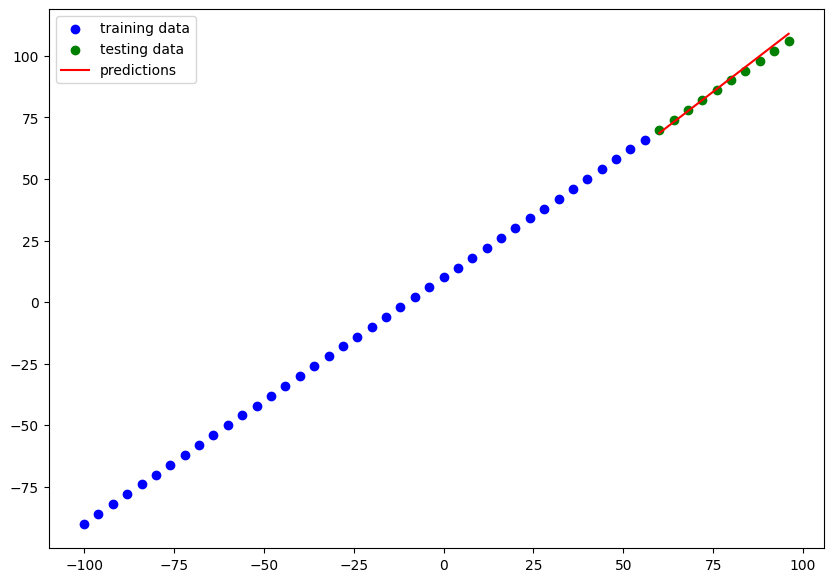

In [ ]:
# make and flaunt predictions for model_1

y_pred_1 = model_1.predict(X_test)
plot_preddictions(predictions = y_pred_1)

In [ ]:
# calculate model_1 evaluation metrics
mae_1 = RegressionMetrics.mae(y_test, y_pred_1)
mse_1 = RegressionMetrics.mse(y_test, y_pred_1)

mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=1.3275337219238281>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.538130044937134>)

#### Build model_2

In [ ]:
# Build model_2
tf.random.set_seed(42)

# 1. create model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#2. compile it
model_2.compile(loss = 'mae',
                optimizer = 'sgd',
                metrics = ['mse'])

#3. fiting it
model_2.fit(X_train, y_train, epochs = 100, verbose =0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


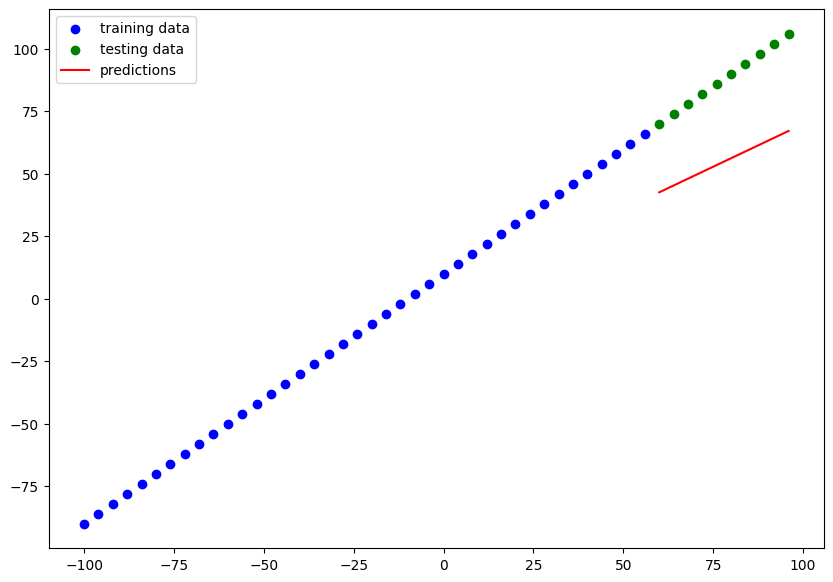

In [ ]:
#visualizing it
y_pred_2 = model_2.predict( X_test)
plot_preddictions(predictions=y_pred_2)

😆 it got worse

In [ ]:
# evaluate it
model_2.evaluate(y_test, y_pred_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - loss: 6.8226 - mse: 46.5474


[6.82256555557251, 46.547401428222656]

In [ ]:
mae_2 = RegressionMetrics.mae(y_test, y_pred_2)
mse_2 = RegressionMetrics.mse(y_test, y_pred_2)

mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=33.14023971557617>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1111.6024169921875>)

#### Build model_3

In [ ]:
# set seed
tf.random.set_seed(42)

#1. create model_3
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#2. compile the model
model_3.compile(loss = 'mae',
              optimizer = 'sgd',
              metrics = ['mae'])

#3. fit the model
model_3.fit(X_train, y_train, epochs = 500, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


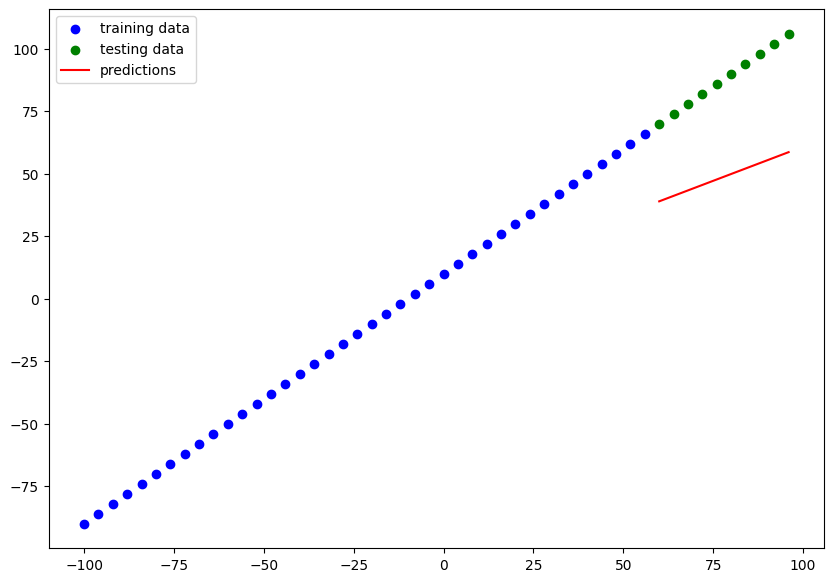

In [ ]:
# make and plot some predictions
y_pred_3 = model_3.predict(X_test)

plot_preddictions(predictions = y_pred_3)

😃 got even  worse

it keeps overfitting

In [ ]:
# evaluating it

mae_3 = RegressionMetrics.mae(y_test, y_pred_3)
mse_3 = RegressionMetrics.mse(y_test, y_pred_3)

mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=39.18463134765625>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1562.58349609375>)

NOTE:
start with small experiments and make the changes by increasing complexity when needed

### Comparing the results of our experiment
We've run a few experiments. Lets compare the results.

In [ ]:
#Lets compare our models result using a pands DataFrame

import pandas as pd

model_results = [["model", mae.numpy(), mse.numpy()],
                ["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns= ["model", "mae", "mse"])
all_results

,model,mae,mse
0,model,2.850753,8.301721
1,model_1,1.327534,2.538130
2,model_2,33.140240,1111.602417
3,model_3,39.184631,1562.583496


In [ ]:
model_2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

> One of the main goals should be to minimize the time between experiments. The more experiments we do, the more we will figure out which don't work and in turn, get closer to figuring out what does work.

### Tracking your experiments
One really good habit in machine learning, is to track you experiments.

Tools to help us:

* TensorBoard - a component of the TensorFlow library to help track modelling experiments (we'll see this one later).
* Weights and Biases - a tool for tracking all of kinds of machhine learning experiments (plugs straight into TensorBoard).


### Saving our Models

Saving our models allows us to use them outside Google Colab (or wherever they were trained) such as in a web application or a mobile apps.

There are 3 main formats we can save our model's to:
1. SavedModel (legacy)
2. HDF5
3. .keras

In [ ]:
# saving the model as .keras
model.save("best_model_yet.keras")

In [ ]:
# saving the model as HDF5
# when you need to use the training model outside of tensorflow
"""will NOT be using this"""
model.save("best_model_HDF5.h5")

In [ ]:
# now the actuall legacy way
"""will NOT be using this"""
model.export("best_model_so_far") # this one creates a folder

Saved artifact at 'best_model_so_far'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135686058871888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687661835408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687661845584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135686058871504: TensorSpec(shape=(), dtype=tf.resource, name=None)


### Load the model back in


In [ ]:
# Load in from saved_model format

# loaded_SavedModel_format = tf.keras.models.load_model("best_model_so_far")

'''File format not supported: filepath=best_model_so_far. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3'''

'File format not supported: filepath=best_model_so_far. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3'

In [ ]:
# loaded_model_hdf5 = tf.keras.models.load_model("/content/best_model_HDF5.h5")
"""This one has problem too. When loading it does not take in custom classes. But defining the custom class for compilation is not easy either. So let h5 be a legacy saving method also. We will not be using it"""

'This one has problem too. When loading it does not take in custom classes. But defining the custom class for compilation is not easy either. So let h5 be a legacy saving method also. We will not be using it'

In [ ]:
# so we are only going to use the .keras model format
load_model_keras = tf.keras.models.load_model("/content/best_model_yet.keras")

In [ ]:
model_pred = model.predict(X_test)
model_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[ 72.195496],
       [ 76.3411  ],
       [ 80.48672 ],
       [ 84.63233 ],
       [ 88.77795 ],
       [ 92.92356 ],
       [ 97.069176],
       [101.21478 ],
       [105.360405],
       [109.50601 ]], dtype=float32)

In [ ]:
load_pred = load_model_keras.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [ ]:
load_pred

array([[ 72.195496],
       [ 76.3411  ],
       [ 80.48672 ],
       [ 84.63233 ],
       [ 88.77795 ],
       [ 92.92356 ],
       [ 97.069176],
       [101.21478 ],
       [105.360405],
       [109.50601 ]], dtype=float32)

In [ ]:
model_pred == load_pred

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
RegressionMetrics.mae(tf.squeeze(model_pred), load_pred).numpy()

np.float32(0.0)

### Download a model (or any other file) from google colab
If you want to download a file from Google Colab:

1. You can go to the `files` tab and right click on the file you are after and click `DOWNLOAD`.
2. use code.

In [ ]:
# download file to local
from google.colab import files
files.download("best_model_yet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# save to Google Drive
#mount your google drive in the files tab
!cp /content/best_model_yet.keras /content/drive/MyDrive/tensorflow_try


In [ ]:
!ls /content/drive/MyDrive/tensorflow_try

best_model_yet.keras


## A larger Example